# 借入総額や返済期間、金利、借入目的などの顧客データを使って、債務不履行リスクを予測するモデルを構築する。

▼データ概要  
課題種別：分類  
データ種別：多変量  
学習データサンプル数：242156  
説明変数の数：9  
欠損値：無  
目的変数について：ChargedOffを1、FullyPaidを0として予測する必要があります。  

・loan_amnt：借入総額  
・term：返済期間  
・interest_rate：金利  
・grade：グレード  
・employment_length：勤続年数  
・purpose：借入の目的  
・credit_score：信用スコア  
・application_type：借入時の申請方式  
・loan_status：返済状況（目的変数）  
  
▼精度評価は、評価関数「F1Score」を使用。  
・評価値は0～1の値をとり、精度が高いほど大きな値になる。  
・暫定評価は、評価用データ全てに対する評価結果になる。

# 【ライブラリ】

In [44]:
# ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# 【データ読み込み】

In [2]:
# データ読み込み
train = pd.read_csv('./train.csv')
train.head()

,id,loan_amnt,term,interest_rate,grade,employment_length,purpose,credit_score,application_type,loan_status
0,88194295,1800.0,3 years,14.49,C4,NaN,debt_consolidation,665.0,Individual,FullyPaid
1,5146039,1200.0,5 years,16.29,C4,2 years,debt_consolidation,700.0,Individual,ChargedOff
2,3095896,2000.0,5 years,21.98,E4,10 years,home_improvement,670.0,Individual,FullyPaid
3,88625044,1000.0,3 years,8.59,A5,4 years,debt_consolidation,710.0,Individual,FullyPaid
4,1178189,1500.0,3 years,13.99,C1,4 years,debt_consolidation,680.0,Individual,FullyPaid


In [73]:
# テストデータ
test = pd.read_csv('./test.csv')
# submitデータ
submit = pd.read_csv('./submit.csv')

In [3]:
# データサイズ確認
train.shape

(242156, 10)

In [4]:
# 目的変数の中の値と出現回数を確認
train['loan_status'].value_counts()

FullyPaid     193815
ChargedOff     48341
Name: loan_status, dtype: int64

↑完済が約80％、貸し倒れが約20％

In [5]:
# 欠損値確認
train.isnull().sum()

id                       0
loan_amnt                0
term                     0
interest_rate            0
grade                    0
employment_length    13185
purpose                  0
credit_score             0
application_type         0
loan_status              0
dtype: int64

今回はデータサイズが約24万と大きい中で欠損値は約1万と小さいので、  
欠損値をすべて削除する。

In [6]:
# 削除前の行数
print(train.shape[0])
# 欠損値削除
train = train.dropna()
# 削除後の行数
print(train.shape[0])

242156
228971


# 【EDA】

In [7]:
# 探索的データ分析
# 基本統計量の確認(量的データ)
train.describe()

,id,loan_amnt,interest_rate,credit_score
count,2.289710e+05,228971.000000,228971.000000,228971.000000
mean,5.570189e+07,1433.415476,13.992611,697.338484
std,4.789707e+07,875.149218,4.846862,31.715229
min,5.571600e+04,100.000000,5.320000,660.000000
25%,3.345535e+06,780.000000,10.640000,675.000000
50%,8.552937e+07,1200.000000,13.490000,690.000000
75%,9.230207e+07,2000.000000,16.990000,715.000000
max,1.264193e+08,4000.000000,30.990000,845.000000


In [8]:
# 基本統計量の確認(質的データ)
train.describe(include=['O'])

,term,grade,employment_length,purpose,application_type,loan_status
count,228971,228971,228971,228971,228971,228971
unique,2,35,11,13,2,2
top,3 years,B3,10 years,debt_consolidation,Individual,FullyPaid
freq,177580,16060,79095,133880,223790,184426


<AxesSubplot:title={'center':'loan_amnt'}, ylabel='Frequency'>

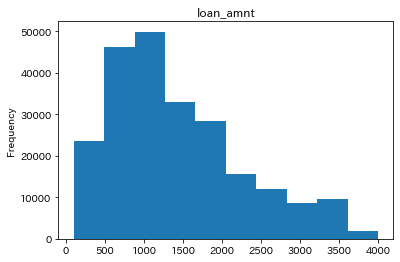

In [9]:
# 量的データの可視化
# loan_amnt
train['loan_amnt'].plot.hist(title='loan_amnt')

<AxesSubplot:title={'center':'interest_rate'}, ylabel='Frequency'>

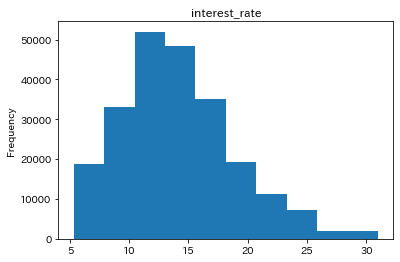

In [10]:
# interest_rate
train['interest_rate'].plot.hist(title='interest_rate')

In [11]:
# 質的データの可視化
# employment_length
train_employment_length_vc = train['employment_length'].value_counts()
train_employment_length_vc

10 years    79095
2 years     22098
3 years     18772
0 years     18511
5 years     16995
1 year      15883
4 years     14895
6 years     13127
7 years     10678
8 years      9938
9 years      8979
Name: employment_length, dtype: int64

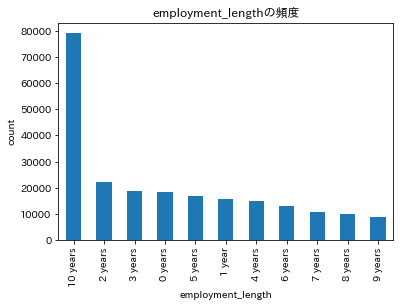

In [12]:
# employment_lengthの可視化
train_employment_length_vc.plot.bar(title='employment_lengthの頻度')
plt.xlabel('employment_length')
plt.ylabel('count')
plt.show()

↑圧倒的に勤続年数10年の割合が多い

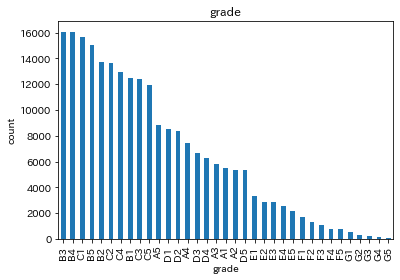

In [13]:
# gradeの可視化
train_grade_vc = train['grade'].value_counts()

train_grade_vc.plot.bar(title='grade')
plt.xlabel('grade')
plt.ylabel('count')
plt.show()

↑B3、B4やC1など5段階評価だと4くらいの割合が多そうな印象

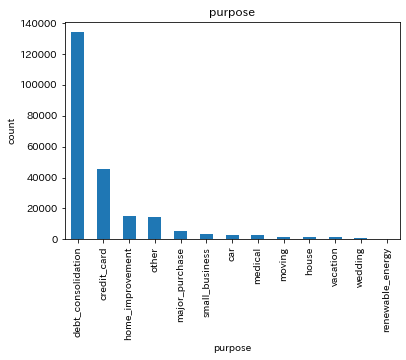

In [14]:
# purposeの可視化
train_purpose_vc = train['purpose'].value_counts()
train_purpose_vc.plot.bar(title='purpose')
plt.xlabel('purpose')
plt.ylabel('count')
plt.show()

↑最多が債務整理、続いてクレジットカード

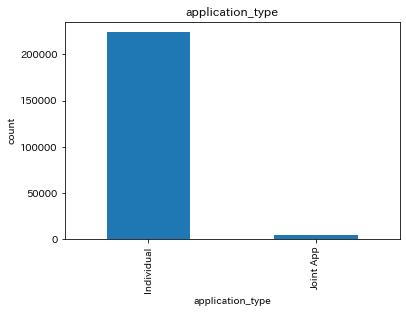

In [15]:
# application_typeの可視化
train_application_type_vc = train['application_type'].value_counts()
train_application_type_vc.plot.bar(title='application_type')
plt.xlabel('application_type')
plt.ylabel('count')
plt.show()

↑ほぼindividualの不均衡データ

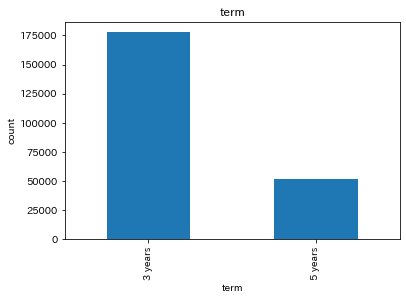

In [16]:
# termの可視化
train_term_vc = train['term'].value_counts()
train_term_vc.plot.bar(title='term')
plt.xlabel('term')
plt.ylabel('count')
plt.show()

↑3年が大多数

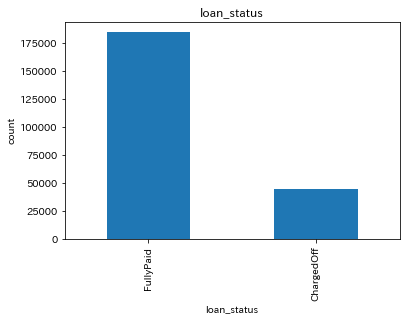

In [17]:
# 予測対象である目的変数(loan_status)も可視化
train['loan_status'].value_counts().plot.bar(title='loan_status')
plt.xlabel('loan_status')
plt.ylabel('count')
plt.show()

・完済と貸し倒れの値に偏りがある  
・完済は約18万、貸し倒れは約5万

# 【仮説立て＆検証】

【仮説立て】  
①借金の総額が多いほど貸し倒れしやすいのではないか  
②高金利であるほど貸し倒れしやすいのではないか  
③信用スコアが低いほど貸し倒れしやすいのではないか  
④返済期間が長いほど貸し倒れしやすいのではないか  
⑤勤続年数が短いほど貸し倒れしやすいのではないか  
⑥グレードが低いほど貸し倒れしやすいのではないか

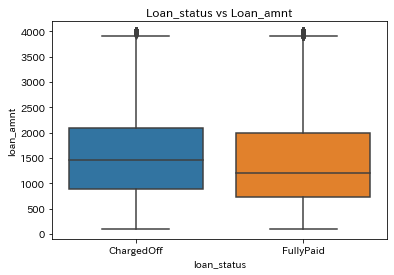

In [18]:
# 仮説①検証のため可視化
sns.boxplot(data=train, x='loan_status', y='loan_amnt')
plt.title('Loan_status vs Loan_amnt')
plt.xlabel('loan_status')
plt.ylabel('loan_amnt')
plt.show()

↑あまり差がないため、モデル作成には使用しない。

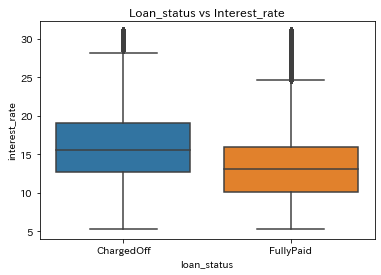

In [19]:
# 仮説②検証のため可視化
sns.boxplot(data=train, x='loan_status', y='interest_rate')
plt.title('Loan_status vs Interest_rate')
plt.xlabel('loan_status')
plt.ylabel('interest_rate')
plt.show()

↑貸し倒れのほうが中央値が大きく、双方に分布の違いが見られるので予測に使えそう

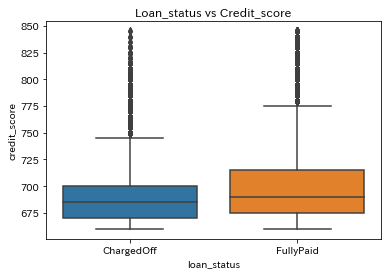

In [20]:
# 仮説③検証のため可視化
sns.boxplot(data=train, x='loan_status', y='credit_score')
plt.title('Loan_status vs Credit_score')
plt.xlabel('loan_status')
plt.ylabel('credit_score')
plt.show()

↑大きな相違はないが、完済のほうが若干値が大きく分布しているので、予測に使う

In [21]:
# 仮説④検証のため可視化
# クロス集計
cross_term = pd.crosstab(train['term'], train['loan_status'], margins=True) # margins=Trueで各カラムのデータ総数
# 割合算出
c_rate = cross_term['ChargedOff'] / cross_term['All']
f_rate = cross_term['FullyPaid'] / cross_term['All']
cross_term['c_rate'] = c_rate
cross_term['f_rate'] = f_rate
cross_term

loan_status,ChargedOff,FullyPaid,All,c_rate,f_rate
term,,,,,
3 years,29339,148241,177580,0.165216,0.834784
5 years,15206,36185,51391,0.295888,0.704112
All,44545,184426,228971,0.194544,0.805456


↑返済期間3年の貸し倒れ率が約16％に対し、期間5年の貸し倒れ率が約29％と跳ね上がっている。  
予測に使えそう。

In [22]:
# 仮説⑤検証のため可視化
# クロス集計
cross_employment_length = pd.crosstab(train['employment_length'], train['loan_status'], margins=True)
# 割合算出
c_rate = cross_employment_length['ChargedOff'] / cross_employment_length['All']
f_rate = cross_employment_length['FullyPaid'] / cross_employment_length['All']
cross_employment_length['c_rate'] = c_rate
cross_employment_length['f_rate'] = f_rate
cross_employment_length

loan_status,ChargedOff,FullyPaid,All,c_rate,f_rate
employment_length,,,,,
0 years,3899,14612,18511,0.210632,0.789368
1 year,3219,12664,15883,0.202670,0.797330
10 years,15013,64082,79095,0.189810,0.810190
2 years,4318,17780,22098,0.195402,0.804598
3 years,3805,14967,18772,0.202696,0.797304
4 years,2933,11962,14895,0.196912,0.803088
5 years,3271,13724,16995,0.192468,0.807532
6 years,2461,10666,13127,0.187476,0.812524
7 years,1998,8680,10678,0.187114,0.812886


↑勤続年数ごとに差はなさそうだが、パッと見分かりづらいので可視化する。

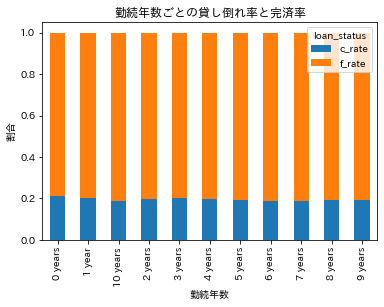

In [23]:
# 可視化の際の不要列を削除
cross_employment_length = cross_employment_length.drop(index=['All'])
# 積み上げ棒グラフ
df_bar = cross_employment_length[['c_rate', 'f_rate']]
df_bar.plot.bar(stacked=True)
plt.title('勤続年数ごとの貸し倒れ率と完済率')
plt.xlabel('勤続年数')
plt.ylabel('割合')
plt.show()

↑やはり勤続年数ごとに差はないので、予測には使わない。

In [24]:
# 仮説⑥検証のため可視化
# クロス集計
cross_grade = pd.crosstab(train['grade'], train['loan_status'], margins=True)
# 割合算出
c_rate = cross_grade['ChargedOff'] / cross_grade['All']
f_rate = cross_grade['FullyPaid'] / cross_grade['All']
cross_grade['c_rate'] = c_rate
cross_grade['f_rate'] = f_rate
cross_grade

loan_status,ChargedOff,FullyPaid,All,c_rate,f_rate
grade,,,,,
A1,194,5316,5510,0.035209,0.964791
A2,244,5128,5372,0.045421,0.954579
A3,337,5486,5823,0.057874,0.942126
A4,539,6916,7455,0.072300,0.927700
A5,744,8054,8798,0.084565,0.915435
B1,1320,11180,12500,0.105600,0.894400
B2,1483,12244,13727,0.108035,0.891965
B3,1966,14094,16060,0.122416,0.877584
B4,2319,13709,16028,0.144684,0.855316


↑これもパッと見わからないので、可視化する。

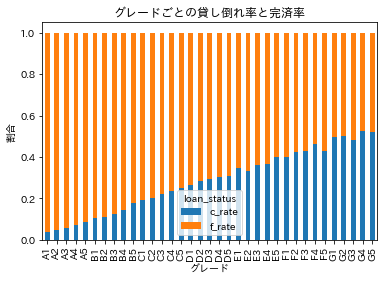

In [25]:
# 可視化の際の不要列を削除
cross_grade = cross_grade.drop(index=['All'])
# 積み上げ棒グラフ
df_bar = cross_grade[['c_rate', 'f_rate']]
df_bar.plot.bar(stacked=True)
plt.title('グレードごとの貸し倒れ率と完済率')
plt.xlabel('グレード')
plt.ylabel('割合')
plt.show()

↑グレードが低くなるにつれて、貸し倒れ率があがっているので、予測に使う。

In [27]:
# 仮説立てが難しい変数について分析
# purposeクロス集計
cross_purpose = pd.crosstab(train['purpose'], train['loan_status'], margins=True)
# 割合算出
c_rate = cross_purpose['ChargedOff'] / cross_purpose['All']
f_rate = cross_purpose['FullyPaid'] / cross_purpose['All']
cross_purpose['c_rate'] = c_rate
cross_purpose['f_rate'] = f_rate
cross_purpose

loan_status,ChargedOff,FullyPaid,All,c_rate,f_rate
purpose,,,,,
car,387,2338,2725,0.142018,0.857982
credit_card,7469,38214,45683,0.163496,0.836504
debt_consolidation,27339,106541,133880,0.204205,0.795795
home_improvement,2604,12439,15043,0.173104,0.826896
house,333,1290,1623,0.205176,0.794824
major_purchase,1003,4423,5426,0.184851,0.815149
medical,531,2046,2577,0.206054,0.793946
moving,358,1325,1683,0.212715,0.787285
other,3077,11250,14327,0.214769,0.785231


↑パッと見わからないので可視化

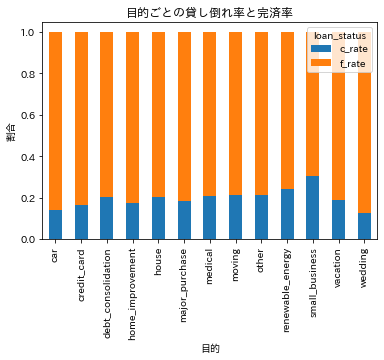

In [28]:
# 可視化の際の不要列を削除
cross_purpose = cross_purpose.drop(index=['All'])
# 積み上げ棒グラフ
df_bar = cross_purpose[['c_rate', 'f_rate']]
df_bar.plot.bar(stacked=True)
plt.title('目的ごとの貸し倒れ率と完済率')
plt.xlabel('目的')
plt.ylabel('割合')
plt.show()

↑目的ごとに貸し倒れ率が異なっているので、予測に使えそう。

In [29]:
# 仮説立てが難しい変数について分析
# application_typeクロス集計
cross_app = pd.crosstab(train['application_type'], train['loan_status'], margins=True)
# 割合算出
c_rate = cross_app['ChargedOff'] / cross_app['All']
f_rate = cross_app['FullyPaid'] / cross_app['All']
cross_app['c_rate'] = c_rate
cross_app['f_rate'] = f_rate
cross_app

loan_status,ChargedOff,FullyPaid,All,c_rate,f_rate
application_type,,,,,
Individual,43223,180567,223790,0.193141,0.806859
Joint App,1322,3859,5181,0.255163,0.744837
All,44545,184426,228971,0.194544,0.805456


↑貸し倒れ率を確認するとindivisualが約19％、jointappが約25％と異なりがあるので、予測に使う。

▼EDAまとめ  
・term、interest_rate、credit_score、grade、purpose、application_typeを予測に使う。

# 【前処理】

In [30]:
# 説明変数と目的変数を作成
x = train[['term', 'interest_rate', 'credit_score', 'grade', 'purpose', 'application_type']]
y = train['loan_status']
print(x.head())
print(y.head())

      term  interest_rate  credit_score grade             purpose  \
1  5 years          16.29         700.0    C4  debt_consolidation   
2  5 years          21.98         670.0    E4    home_improvement   
3  3 years           8.59         710.0    A5  debt_consolidation   
4  3 years          13.99         680.0    C1  debt_consolidation   
5  3 years           7.35         790.0    A4      major_purchase   

  application_type  
1       Individual  
2       Individual  
3       Individual  
4       Individual  
5       Individual  
1    ChargedOff
2     FullyPaid
3     FullyPaid
4     FullyPaid
5     FullyPaid
Name: loan_status, dtype: object


In [31]:
# 質的変数をダミー変数化
x_dum = pd.get_dummies(x)
y_dum = pd.get_dummies(y)
print(x_dum.head())
print(y_dum.head())

   interest_rate  credit_score  term_3 years  term_5 years  grade_A1  \
1          16.29         700.0             0             1         0   
2          21.98         670.0             0             1         0   
3           8.59         710.0             1             0         0   
4          13.99         680.0             1             0         0   
5           7.35         790.0             1             0         0   

   grade_A2  grade_A3  grade_A4  grade_A5  grade_B1  ...  \
1         0         0         0         0         0  ...   
2         0         0         0         0         0  ...   
3         0         0         0         1         0  ...   
4         0         0         0         0         0  ...   
5         0         0         1         0         0  ...   

   purpose_major_purchase  purpose_medical  purpose_moving  purpose_other  \
1                       0                0               0              0   
2                       0                0          

In [32]:
# 予測対象カラムの選択
# ダミー変数化によって予測対象が2つになった
# 今回は貸し倒れ率を検出したいため、ChargedOffを選択する
y_dum = y_dum.drop(columns=['FullyPaid'])
y_dum.head()

,ChargedOff
1,1
2,0
3,0
4,0
5,0


# 【モデル構築】

In [35]:
# 学習データと評価データに分割
# 予測対象が不均衡データだったので、stratifyを指定することで、学習と評価を同じ比率に分割
X_train, X_test, y_train, y_test = train_test_split(x_dum, y_dum, random_state=0, stratify=y_dum['ChargedOff'])
print(X_train.shape)
print(X_test.shape)

(171728, 54)
(57243, 54)


In [41]:
# モデルの学習
lr = LogisticRegression()
lr.fit(X_train, y_train)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1107: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [42]:
# 予測の実行
pred = lr.predict(X_test)
pred

array([0, 0, 0, ..., 0, 0, 0], dtype=uint8)

In [43]:
# 評価関数にて評価
f_one = f1_score(y_test, pred)
f_one

0.034458753915767484

↑限りなく0に近く、精度が悪い状態なので、原因追求すべく混同行列を確認

In [46]:
cm = confusion_matrix(y_test, pred)
cm

array([[45949,   158],
       [10938,   198]])

↑左下のFNが多い？実際は1なのに0と予測している、つまりは実際は貸し倒れなのに完済と予測しているサンプルが多い。  

# 【モデル改善】

In [54]:
# しきい値調整
# predict_probaで分類結果でなく確率値を出力
pred_proba = lr.predict_proba(X_test)
# データフレーム型変換
proba_df = pd.DataFrame(pred_proba)
proba_df

,0,1
0,0.839141,0.160859
1,0.933136,0.066864
2,0.867908,0.132092
3,0.899127,0.100873
4,0.638896,0.361104
...,...,...
57238,0.620001,0.379999
57239,0.764957,0.235043
57240,0.870252,0.129748
57241,0.834334,0.165666


In [55]:
# 上記の確率値を用いてしきい値を決めていく
# y_test内のChargedOffカラムの合計値算出
chargedoff_val = y_test['ChargedOff'].sum()
chargedoff_val

11136

In [56]:
# 1である確率を降順で並べ替え
proba_desc = proba_df[1].sort_values(ascending=False)
# y_test内のChargedOffカラムの値が1であるデータ数と同じ行番号のデータを抜き出す
threshold = proba_desc.iloc[11136]
threshold

0.27523646782271494

↑これをしきい値として設定する

In [57]:
# しきい値以上は1、それ以外は0とする関数を作成
def classification(x):
    if x >= threshold:
        return 1
    else:
        return 0

In [59]:
# 関数が使えるかテスト
print(classification(0.27))
print(classification(0.28))

0
1


In [60]:
# 関数を使って分類実行
proba_df['class_new'] = proba_df[1].apply(classification)
proba_df.head()

,0,1,class_new
0,0.839141,0.160859,0
1,0.933136,0.066864,0
2,0.867908,0.132092,0
3,0.899127,0.100873,0
4,0.638896,0.361104,1


In [61]:
# f1_scoreにて評価
f_one_2 = f1_score(y_test, proba_df['class_new'])
f_one_2

0.3472484064996858

↑精度改善できた。さらに混同行列を確認してモデル改善する。

In [62]:
# 混同行列の表示
cm2 = confusion_matrix(y_test, proba_df['class_new'])
cm2

array([[38833,  7274],
       [ 7268,  3868]])

↑右上の本当は完済しているのに、貸し倒れると予測しているのが約7200件もある。。

In [64]:
X_train.shape

(171728, 54)

In [63]:
# ダウンサンプリングを試す
train = pd.concat([X_train, y_train], axis=1)
train.shape

(171728, 55)

In [66]:
# 完済データと貸し倒れデータを別々の変数に代入
fp = train[train['ChargedOff'] == 0]
co = train[train['ChargedOff'] == 1]
co.shape[0] # 貸し倒れのデータ数

33409

In [67]:
# 貸し倒れのデータ数と同数だけ完済データをランダム抽出
fp = fp.sample(n = 33409, random_state=0)
fp.shape[0]

33409

In [68]:
# 再度、完済データと貸し倒れデータを縦結合
train = pd.concat([fp, co])
# 説明変数と目的変数をそれぞれ別の変数に代入
X_train = train.drop(columns=['ChargedOff'])
y_train = train['ChargedOff']
print(X_train.head())
print(y_train.head())

        interest_rate  credit_score  term_3 years  term_5 years  grade_A1  \
163163          13.99         690.0             1             0         0   
197190           6.03         750.0             1             0         1   
186131           8.90         720.0             1             0         0   
125298          23.83         685.0             0             1         0   
157071          11.14         715.0             1             0         0   

        grade_A2  grade_A3  grade_A4  grade_A5  grade_B1  ...  \
163163         0         0         0         0         0  ...   
197190         0         0         0         0         0  ...   
186131         0         0         0         1         0  ...   
125298         0         0         0         0         0  ...   
157071         0         0         0         0         0  ...   

        purpose_major_purchase  purpose_medical  purpose_moving  \
163163                       0                0               0   
197190      

In [69]:
# 再度モデル学習
lr2 = LogisticRegression()
lr2.fit(X_train, y_train)
# 再度評価データ予測
pred2 = lr2.predict(X_test)
pred2

/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, ..., 0, 0, 0], dtype=uint8)

In [70]:
# f1_scoreの算出
f_one_3 = f1_score(y_test, pred2)
f_one_3

0.38637120532855135

↑予測精度改善できた。

In [71]:
# 混同行列の確認
cm3 = confusion_matrix(y_test, pred2)
cm3

array([[25749, 20358],
       [ 3595,  7541]])

・貸し倒れ件数を7500的中させることができた。  
・ただ、本当は完済しているのに貸し倒れると予測しているのが約2万件出てしまっている。  
・予測モデルは単に精度評価指標を確認するだけでは不十分なことも多く、  
ROIや倫理的視点も鑑みながら、運用方法について検討すべきである。

In [102]:
target_pred = pd.Series(pred2, name='y')
target_pred = pd.DataFrame(target_pred)
target_pred.head()

,y
0,0
1,0
2,0
3,0
4,1


In [105]:
target_pred = target_pred.drop(range(26906,57243))
target_pred.shape

(26906, 1)

In [106]:
submit_data = pd.concat([test['id'], target_pred], axis=1)
submit_data.to_csv('submission.csv', header=None, index=False)